In [1]:
import os, re, json, hashlib
from pathlib import Path
from typing import List, Dict, Any, Optional
from dataclasses import dataclass, asdict
from datetime import datetime
from collections import Counter

@dataclass
class KnowledgeBlock:
    id: str; content: str; block_type: str; file_path: str
    concept_hierarchy: List[str]; headings: List[str]
    language: Optional[str] = None
    prev_block_id: Optional[str] = None; next_block_id: Optional[str] = None
    metadata: Dict[str, Any] = None

class OIWikiProcessor:
    def __init__(self, docs_path="./docs"):
        self.docs_path = Path(docs_path)
        self.blocks = []
        self.skip_patterns = ['edit-landing', 'index.md', 'landing.md', 'README.md',
                            '_category_', 'disqus', 'pagetime', 'contributing',
                            'htc.md', 'format.md', 'about.md']
    
    def is_technical(self, file_path, content, headings=None):
        path = str(file_path).lower()
        if any(p in path for p in self.skip_patterns): return False
        if headings and len(headings) > 0:
            if any(x in headings[0].lower() for x in ['如何参与', '格式手册', '关于我们', '贡献']): return False
        return '```' in content or any(kw in content.lower() for kw in ['算法', '数据结构', '实现', '复杂度', '代码'])
    
    def extract_concepts(self, file_path):
        """直接从路径层级构建概念，不进行任何映射"""
        path = str(file_path).replace('\\', '/')
        path = path.replace('.md', '')
        if 'docs/' in path: 
            path = path.split('docs/')[-1]
        parts = [p for p in path.split('/') if p and not p.startswith('_')]
        concepts = []
        
        for p in parts:
            p = re.sub(r'[-_]', ' ', p)
            p = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', p)
            concepts.append(p)
        
        return concepts if concepts else ['root']
    
    def split_by_headings(self, content):
        lines, sections, current = content.split('\n'), [], {'headings': [], 'content': []}
        for line in lines:
            m = re.match(r'^(#{1,6})\s+(.+)$', line)
            if m:
                if current['content']: sections.append(current)
                level, title = len(m.group(1)), m.group(2).strip()
                new_headings = [h for h in current['headings'] if h['level'] < level]
                new_headings.append({'level': level, 'title': title})
                current = {'headings': new_headings, 'content': [line]}
            else: current['content'].append(line)
        if current['content']: sections.append(current)
        return sections
    
    def analyze_code(self, code, lang):
        metrics = {'line_count': len(code.split('\n')), 'functions': []}
        if lang in ['cpp', 'python', 'py']:
            funcs = re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\([^)]*\)\s*[{:]', code)
            metrics['functions'] = list(set(funcs))[:3]
        return metrics
    def process_file(self, file_path: Path):
        """处理单个文件，解析代码包含并提取所有代码块"""
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
        except:
            return
        
        # 获取相对路径
        try:
            rel_path = str(file_path.relative_to(self.docs_path))
        except ValueError:
            rel_path = file_path.name
        
        # 如果不是技术内容，跳过
        if not self.is_technical(rel_path, content):
            return
        
        # 解析 --8<-- 语法，读取实际代码
        content = self.resolve_code_includes(content, file_path)
        
        # 提取概念层级
        concepts = self.extract_concepts(rel_path)
        
        # 按标题分割并处理每个section
        sections = self.split_by_headings(content)
        for section in sections:
            headings = [h['title'] for h in section['headings']]
            if self.is_technical(rel_path, '\n'.join(section['content']), headings):
                self.blocks.extend(self.process_section(section, rel_path, concepts.copy()))
    def resolve_code_includes(self, content, file_path):
        """递归解析 --8<-- 代码包含语法（支持 :core, :full-text 等片段）"""
        pattern = r'--8<--\s*"([^"]+)"'
        
        def replace(match):
            ref = match.group(1)
            
            # 分离文件路径和片段标识
            parts = ref.split(':')
            rel_path = parts[0]
            fragment = parts[1] if len(parts) > 1 else None
            
            # 修复路径：去掉开头的 docs/
            if rel_path.startswith('docs/'):
                rel_path = rel_path[5:]
            
            # 尝试多个可能的路径
            possible_paths = [
                self.docs_path / rel_path,  # docs/basic/code/xxx/xxx.py
                self.docs_path / rel_path.replace('code/', 'code/'),  # 原样
                Path(str(self.docs_path).replace('docs', 'docs')) / rel_path,  # 去重
            ]
            
            for full_path in possible_paths:
                if full_path.exists():
                    try:
                        with open(full_path, 'r', encoding='utf-8') as f:
                            code = f.read()
                        
                        # 提取片段
                        if fragment:
                            code = self.extract_code_fragment(code, fragment)
                        
                        return self.resolve_code_includes(code, full_path)
                    except:
                        continue
            
            return f"// 无法加载代码文件: {ref}\n"
        
        return re.sub(pattern, replace, content)
    def extract_code_fragment(self, code, fragment):
        """提取代码中的特定片段（:core, :full-text 等）"""
        if fragment == 'full-text':
            return code
        
        # 匹配标记之间的内容
        # <!-- BEGIN:core --> ... <!-- END:core -->
        pattern = rf'<!--\s*BEGIN:{fragment}\s*-->(.*?)<!--\s*END:{fragment}\s*-->'
        match = re.search(pattern, code, re.DOTALL)
        if match:
            return match.group(1).strip()
        
        # 如果没有找到标记，返回全部代码
        return code
    def process_section(self, section, file_path, base_concepts):
        content = '\n'.join(section['content'])
        headings = [h['title'] for h in section['headings']]
        concepts = base_concepts + headings
        blocks, pos = [], 0
        
        # 提取所有代码块（包括折叠块内的）
        code_blocks = self.extract_all_code_blocks(content)
        code_blocks.sort(key=lambda x: x['start'])
        
        for cb in code_blocks:
            # 代码块前的文本
            if cb['start'] > pos:
                text = content[pos:cb['start']].strip()
                if text:
                    block = self.create_block(
                        text, 'markdown', file_path, concepts, headings
                    )
                    blocks.append(block)
            
            # 代码块
            lang = cb['lang']
            code = cb['code']
            
            # 自动检测语言（如果是text但看起来像代码）
            if lang == 'text':
                if '#include' in code or 'using namespace' in code:
                    lang = 'cpp'
                elif 'def ' in code or 'import ' in code:
                    lang = 'python'
                elif 'public class' in code or 'System.out' in code:
                    lang = 'java'
            
            block = self.create_block(
                code, 'code', file_path, concepts, headings,
                lang, {'code_metrics': self.analyze_code(code, lang)}
            )
            blocks.append(block)
            
            pos = cb['end']
        
        # 剩余文本
        if pos < len(content):
            text = content[pos:].strip()
            if text:
                block = self.create_block(
                    text, 'markdown', file_path, concepts, headings
                )
                blocks.append(block)
        
        # 设置前后链接
        for i in range(len(blocks)-1):
            blocks[i].next_block_id = blocks[i+1].id
            blocks[i+1].prev_block_id = blocks[i].id
        
        return blocks

    def extract_all_code_blocks(self, content):
        """提取所有代码块（包括折叠块内的）"""
        code_blocks = []
        
        # 1. 普通代码块
        for m in re.finditer(r'```(\w*)\n(.*?)```', content, re.DOTALL):
            lang = m.group(1).lower() or 'text'
            code = m.group(2).strip()
            if len(code) > 10:  # 过滤太短的
                code_blocks.append({
                    'lang': lang,
                    'code': code,
                    'start': m.start(),
                    'end': m.end()
                })
        
        # 2. 折叠块内的代码块
        for m in re.finditer(r'\?\?\? note.*?\n(.*?)\?\?\?', content, re.DOTALL):
            note_content = m.group(1)
            for cm in re.finditer(r'```(\w*)\n(.*?)```', note_content, re.DOTALL):
                lang = cm.group(1).lower() or 'text'
                code = cm.group(2).strip()
                if len(code) > 10:
                    code_blocks.append({
                        'lang': lang,
                        'code': code,
                        'start': m.start() + cm.start(),
                        'end': m.start() + cm.end()
                    })
        
        return code_blocks
    def create_block(self, content, btype, fpath, concepts, headings, lang=None, meta=None):
        cid = f"blk_{datetime.now().strftime('%Y%m%d')}_{hashlib.md5(f'{fpath}:{content[:200]}'.encode()).hexdigest()[:8]}"
        return KnowledgeBlock(id=cid, content=content, block_type=btype, file_path=fpath,
                            concept_hierarchy=concepts, headings=headings, language=lang,
                            metadata=meta or {})
    
    
    def run(self, max_files=None, silent=True):
        files = [f for f in self.docs_path.rglob("*.md") 
                if not any(p in str(f).lower() for p in self.skip_patterns)]
        if max_files: files = files[:max_files]
        if not silent: print(f"处理 {len(files)} 个文件")
        for i, f in enumerate(files):
            self.process_file(f)
            if not silent and i % 100 == 0 and i > 0: print(f"进度: {i}/{len(files)}")
        return self.blocks
    
    def save(self, output_path):
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, 'w', encoding='utf-8') as f:
            for b in self.blocks:
                d = asdict(b)
                # 移除content_preview（如果有）
                d.pop('content_preview', None)
                # 单行输出，不加indent
                f.write(json.dumps(d, ensure_ascii=False) + '\n')

def process_oiwiki(docs_path="./docs", output_path="./oiwiki_blocks.jsonl", max_files=None, silent=False):
    p = OIWikiProcessor(docs_path)
    p.run(max_files, silent)
    count = p.save(output_path)
    if not silent: print(f"完成: {count} 个知识块 -> {output_path}")
    return p

if __name__ == "__main__":
    processor = process_oiwiki("./docs", "./oiwiki_blocks.jsonl", silent=False)
    types = Counter(b.block_type for b in processor.blocks)
    concepts = Counter()
    for b in processor.blocks:
        if b.concept_hierarchy: concepts[b.concept_hierarchy[0]] += 1
    
    print(f"\n块类型: {dict(types)}")
    print(f"顶级概念: {dict(concepts.most_common(5))}")

处理 441 个文件
进度: 100/441
进度: 200/441
进度: 300/441
进度: 400/441
完成: None 个知识块 -> ./oiwiki_blocks.jsonl

块类型: {'markdown': 3848, 'code': 2019}
顶级概念: {'lang': 1111, 'math': 953, 'ds': 931, 'graph': 692, 'tools': 481}


In [3]:
# T1.1 - 向量化
import os
# 注释掉或删除镜像源设置
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import json
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# 1. 加载模型（直接从官方源下载）
print("正在从 Hugging Face 官方源加载模型...")
model = SentenceTransformer("BAAI/bge-small-zh-v1.5")
print(f"模型加载完成，维度: {model.get_sentence_embedding_dimension()}")

# 2. 读取块
blocks = []
with open("./oiwiki_blocks.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        blocks.append(json.loads(line))
print(f"读取 {len(blocks)} 个块")
print(f"代码块: {len([b for b in blocks if b['block_type'] == 'code'])} 个")

# 3. 构建检索文本
texts = []
valid_blocks = []
for b in tqdm(blocks):
    concepts = " → ".join(b.get("concept_hierarchy", []))
    content = b.get("content", "")[:800]
    
    if b["block_type"] == "code":
        lang = b.get("language", "text")
        text = f"{concepts} [{lang}代码] {content}"
    else:
        headings = " ".join(b.get("headings", []))
        text = f"{concepts} {headings} {content}"
    
    texts.append(text)
    valid_blocks.append(b)

# 4. 向量化
embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=True, batch_size=64)

# 5. 保存
np.save("./embeddings.npy", embeddings)

mapping = []
for i, b in enumerate(valid_blocks):
    mapping.append({
        "id": b["id"],
        "index": i,
        "file_path": b["file_path"],
        "block_type": b["block_type"],
        "concept_hierarchy": b["concept_hierarchy"],
        "language": b.get("language", "unknown"),
        "headings": b.get("headings", [])[:2]
    })

with open("./mapping.json", "w", encoding="utf-8") as f:
    json.dump(mapping, f, ensure_ascii=False, indent=2)

print(f"完成！向量维度: {embeddings.shape[1]}, 块数: {len(mapping)}")

正在从 Hugging Face 官方源加载模型...


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 1088.17it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型加载完成，维度: 512
读取 5867 个块
代码块: 2019 个


Batches: 100%|██████████| 92/92 [01:27<00:00,  1.05it/s]


完成！向量维度: 512, 块数: 5867


In [ ]:
#T1.2
import json
import numpy as np
import faiss

# 1. 加载向量
embeddings = np.load("./embeddings.npy")
print(f"加载向量: {embeddings.shape}")

# 2. 构建索引
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings.astype(np.float32))

# 3. 保存
faiss.write_index(index, "./faiss.index")
print(f"索引构建完成，规模: {index.ntotal}")

# 4. 简单测试
with open("./mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)

query_vec = embeddings[0].astype(np.float32).reshape(1, -1)
scores, indices = index.search(query_vec, 3)
print("\n测试检索:")
for i, idx in enumerate(indices[0]):
    if idx != -1:
        print(f"  {i+1}. 得分: {scores[0][i]:.4f} | {' → '.join(mapping[idx]['concept_hierarchy'])}")

加载向量: (5867, 512)
索引构建完成，规模: 5867

测试检索:
  1. 得分: 1.0000 | basic → amortized analysis
  2. 得分: 0.8715 | basic → complexity → 均摊复杂度
  3. 得分: 0.7939 | basic → complexity → 时间复杂度


In [ ]:
import json
import numpy as np
import faiss
from rank_bm25 import BM25Okapi
import jieba
from sentence_transformers import SentenceTransformer
from IPython.display import clear_output

# 1. 加载模型和索引
print("加载模型...")
#model = SentenceTransformer("BAAI/bge-small-zh-v1.5")
index = faiss.read_index("./faiss.index")

with open("./mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)
idx_to_meta = {i: m for i, m in enumerate(mapping)}

# 2. 加载原始块（保持JSONL的行顺序）
print("加载知识库...")
blocks_list = []  # 按行顺序存储
blocks_dict = {}  # ID索引
with open("./oiwiki_blocks.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        b = json.loads(line)
        blocks_list.append(b)
        blocks_dict[b["id"]] = b

# 3. 构建BM25索引
print("构建BM25索引...")
valid_blocks = [blocks_dict[m["id"]] for m in mapping if m["id"] in blocks_dict]
corpus = [list(jieba.cut(b.get("content", "")[:1000])) for b in valid_blocks]
bm25 = BM25Okapi(corpus)
print(f"BM25索引完成，规模: {len(corpus)}")

# 4. 检索器类
class OIRetriever:
    def __init__(self):
        self.index = index
        self.idx_to_meta = idx_to_meta
        self.blocks_dict = blocks_dict
        self.blocks_list = blocks_list  # 按行顺序的列表
        self.bm25 = bm25
    def search_next_cpp(self, start_line):
        """从start_line往后找最近的C++代码块"""
        for i in range(start_line + 1, len(self.blocks_list)):
            block = self.blocks_list[i]
            if block.get("block_type") == "code":
                lang = block.get("language", "").lower()
                if lang in ["cpp", "c++", "cc", "hpp"]:
                    return {
                        "line": i,
                        "content": block.get("content", ""),
                        "id": block.get("id"),
                        "language": block.get("language")
                    }
        return None

    def search_next_python(self, start_line):
        """从start_line往后找最近的Python代码块"""
        for i in range(start_line + 1, len(self.blocks_list)):
            block = self.blocks_list[i]
            if block.get("block_type") == "code":
                lang = block.get("language", "").lower()
                if lang in ["python", "py"]:
                    return {
                        "line": i,
                        "content": block.get("content", ""),
                        "id": block.get("id"),
                        "language": block.get("language")
                    }
        return None
    def search(self, query, top_k=3, alpha=0.6):
        query_vec = model.encode(query, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
        vec_scores, vec_indices = self.index.search(query_vec, 30)
        
        tokens = list(jieba.cut(query))
        bm25_scores = self.bm25.get_scores(tokens)
        bm25_top = np.argsort(bm25_scores)[-30:][::-1]
        
        scores_dict = {}
        for idx, score in zip(vec_indices[0], vec_scores[0]):
            if idx != -1:
                scores_dict[idx] = alpha * score
        
        for i, idx in enumerate(bm25_top):
            score = bm25_scores[idx] / 5
            scores_dict[idx] = scores_dict.get(idx, 0) + (1 - alpha) * score
        
        sorted_idx = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)[:top_k]
        
        results = []
        for idx, score in sorted_idx:
            meta = self.idx_to_meta[idx]
            block = self.blocks_dict.get(meta["id"], {})
            results.append({
                "id": meta["id"],
                "score": score,
                "block_type": meta["block_type"],
                "language": meta.get("language"),
                "concept_hierarchy": meta["concept_hierarchy"],
                "file_path": meta["file_path"],
                "content": block.get("content", ""),
                "line_index": self.get_line_index(meta["id"])  # 获取在JSONL中的行号
            })
        return results
    
    def get_line_index(self, block_id):
        """获取块在JSONL文件中的行号"""
        for i, block in enumerate(self.blocks_list):
            if block["id"] == block_id:
                return i
        return -1
def interactive_search():
    retriever = OIRetriever()
    print("\n✅ OI-Wiki 检索器已启动\n")
    
    while True:
        query = input("🔍 请输入查询（输入q退出）: ")
        if query.lower() in ['q', 'quit', 'exit']:
            break
        
        print("\n正在检索...")
        results = retriever.search(query, top_k=3)
        
        # 清空并只输出三个结果的具体信息
        clear_output(wait=True)
        print(f"🔍 查询: {query}\n")
        print("="*80)
        print("【检索结果】")
        print("="*80)
        
        for i, r in enumerate(results):
            print(f"\n[{i+1}] 得分: {r['score']:.4f}")
            print(f"    路径: {' → '.join(r['concept_hierarchy'])}")
            print(f"    类型: {r['block_type']} | 语言: {r.get('language', 'unknown')}")
            print(f"    行号: {r['line_index']}")
            print("-"*40)
            print(f"{r['content'][:500]}{'...' if len(r['content']) > 500 else ''}")
            print("-"*40)
        
        # 选择结果
        choice = input("\n📌 请选择要处理的结果编号 (1-3，输入0重新查询): ")
        if choice == '0':
            continue
        if choice not in ['1', '2', '3']:
            print("无效输入")
            continue
        
        idx = int(choice) - 1
        current_block = results[idx]
        current_line = current_block['line_index']
        
        # 结果操作循环
        while True:
            print("\n" + "="*80)
            print(f"【当前结果】行号: {current_line} | 类型: {current_block['block_type']}")
            print("="*80)
            
            action = input("请选择操作 - [n]下一个块 [c]C++代码 [p]Python代码 [q]退出: ").lower()
            
            if action == 'n':
                next_line = current_line + 1
                if next_line < len(retriever.blocks_list):
                    next_block = retriever.blocks_list[next_line]
                    print(f"\n【下一个块】行号: {next_line}")
                    print("-"*40)
                    print(next_block.get('content', '')[:500])
                    print("-"*40)
                    current_line = next_line
                    current_block = next_block
                else:
                    print("⚠️ 已经是最后一行")
            
            elif action == 'c':
                cpp_block = retriever.search_next_cpp(current_line)
                if cpp_block:
                    print(f"\n【C++代码】行号: {cpp_block['line']}")
                    print("-"*40)
                    print(cpp_block['content'][:500])
                    print("-"*40)
                else:
                    print("⚠️ 未找到C++代码块")
            
            elif action == 'p':
                py_block = retriever.search_next_python(current_line)
                if py_block:
                    print(f"\n【Python代码】行号: {py_block['line']}")
                    print("-"*40)
                    print(py_block['content'][:500])
                    print("-"*40)
                else:
                    print("⚠️ 未找到Python代码块")
            
            elif action == 'q':
                break
            
            else:
                print("无效输入，请选择 n/c/p/q")
        
        # 返回结果列表，重新查询
        clear_output(wait=True)
interactive_search()

🔍 查询: 1111

【检索结果】

[1] 得分: 0.6113
    路径: graph → steiner tree → 例题
    类型: code | 语言: cpp
    行号: 2123
----------------------------------------
#include <cstring>
#include <iostream>
#include <queue>

using namespace std;

#define mp make_pair
using P = pair<int, int>;
using PP = pair<P, int>;
constexpr int INF = 0x3f3f3f3f;
constexpr int dx[] = {0, 0, -1, 1};
constexpr int dy[] = {1, -1, 0, 0};
int n, m, K, root;
int f[101][1111], a[101], ans[11][11];
bool inq[101];
PP pre[101][1111];
queue<P> q;

bool legal(P u) {
  if (u.first >= 0 && u.second >= 0 && u.first < n && u.second < m) {
    return true;
  }
  return false;
}

int num(P u)...
----------------------------------------

[2] 得分: 0.3268
    路径: contest → interaction → CF679A Bear and Prime 100
    类型: code | 语言: cpp
    行号: 406
----------------------------------------
#include <cstdio>
    constexpr int prime[] = {2,  3,  4,  5,  7,  9,  11, 13, 17, 19,
                             23, 25, 29, 31, 37, 41, 43, 47, 49};
    in

C:\Users\26217\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


加载知识库...
总块数: 5867
代码块数: 2019

T2.1 纯向量检索实验


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 911.05it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 71/71 [00:00<00:00, 1070.69it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: moka-ai/m3e-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No sentence-transformers model found with name microsoft/codebert-base. Creating a new one with mean pooling.
Loading weights: 


实验: bge-small-zh + content


Batches: 100%|██████████| 184/184 [01:14<00:00,  2.46it/s]


...

代码块命中率: 0.1333

优化方案: enhanced


Batches: 100%|██████████| 184/184 [01:23<00:00,  2.21it/s]


代码块命中率: 0.2000

优化方案: lang_only


Batches: 100%|██████████| 184/184 [01:20<00:00,  2.29it/s]


代码块命中率: 0.1333

实验结果汇总

【T2.1 向量检索 Top3】
codebert        code       0.9841
codebert        content    0.9840
codebert        concept    0.9800

【T2.2 关键词检索最佳参数】
最佳k1=0.5, 得分=22.9236

【T2.3 混合检索最佳权重】
最佳alpha=0.3, 得分=2.1028

【T2.4 代码优化效果】
enhanced   代码命中率: 0.2000
baseline   代码命中率: 0.1333
lang_only  代码命中率: 0.1333


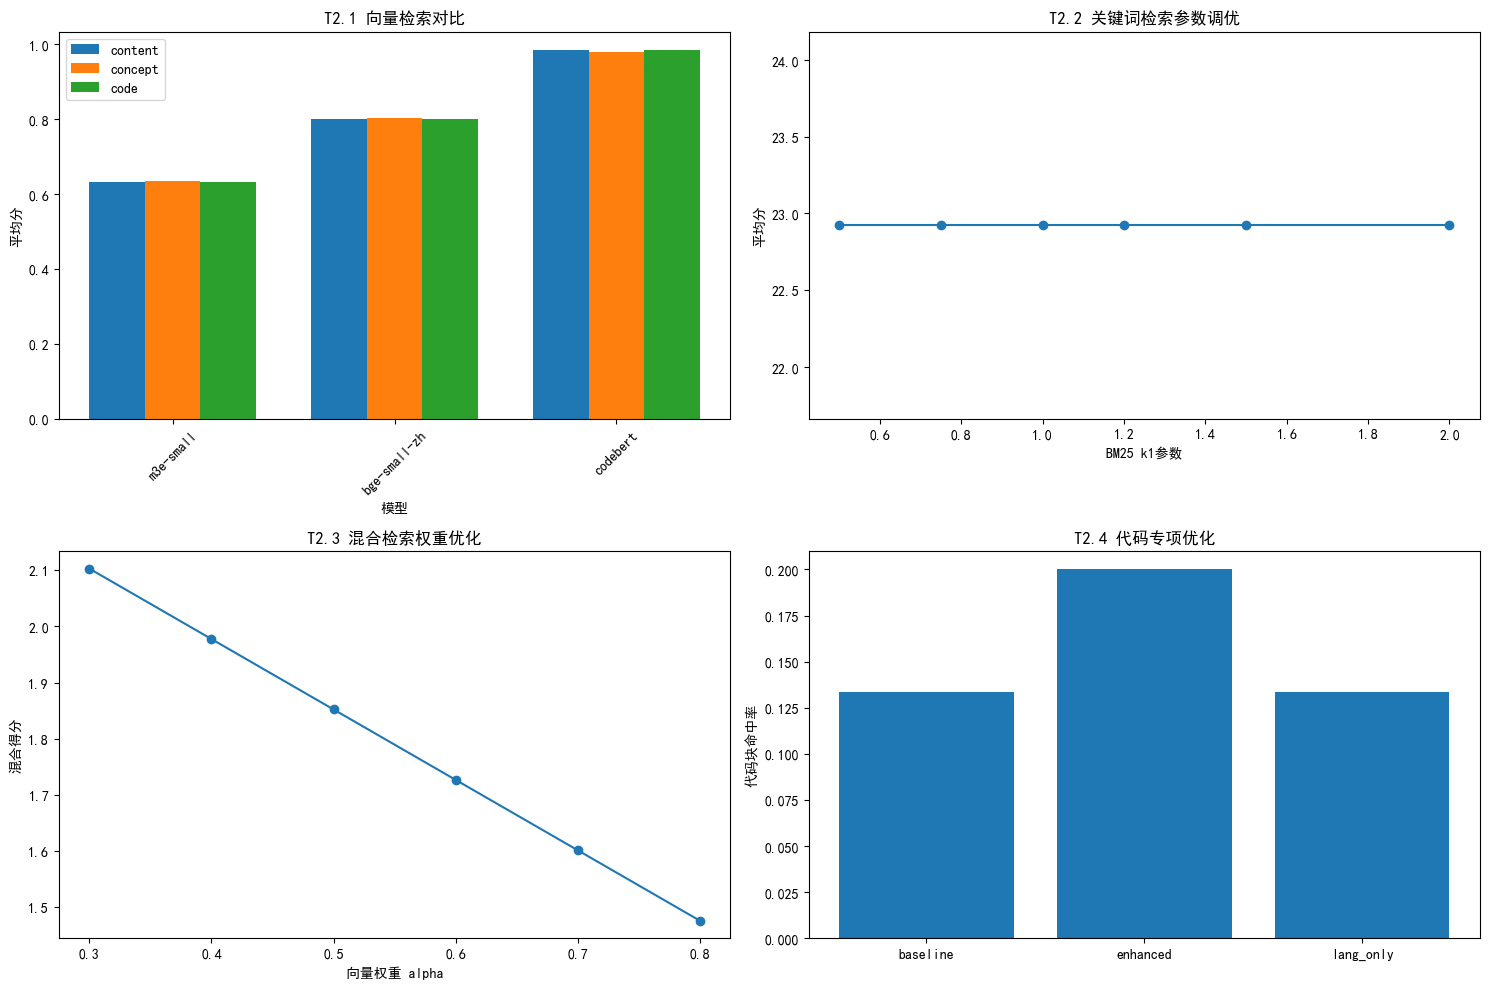


✅ 实验完成！结果已保存至 ./t2_experiment_results.png


In [4]:
import json
import numpy as np
import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import jieba
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# ========== 中文显示修复 ==========
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# 下面是你原来的所有代码，不用动
# ============ 1. 加载数据 ============
print("加载知识库...")
blocks = []
with open("./oiwiki_blocks.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        blocks.append(json.loads(line))
print(f"总块数: {len(blocks)}")
print(f"代码块数: {len([b for b in blocks if b['block_type'] == 'code'])}")

# ============ 2. 定义查询集 ============
queries = [
    "线段树区间修改 代码",
    "SPFA SLF优化 cpp", 
    "快速排序 实现",
    "Dijkstra 堆优化",
    "并查集路径压缩",
    "KMP 匹配",
    "01背包 动态规划",
    "LCA 倍增",
    "网络流 Dinic",
    "主席树 第k小"
]

# ============ 3. T2.1 纯向量检索实验 ============
print("\n" + "="*60)
print("T2.1 纯向量检索实验")
print("="*60)

models = {
    "bge-small-zh": SentenceTransformer("BAAI/bge-small-zh-v1.5"),
    "m3e-small": SentenceTransformer("moka-ai/m3e-small"),
    "codebert": SentenceTransformer("microsoft/codebert-base"),
}

strategies = {
    "content": lambda b: b.get("content", "")[:512],
    "concept": lambda b: " → ".join(b.get("concept_hierarchy", [])) + " " + b.get("content", "")[:512],
    "code": lambda b: f"[{b.get('language', 'text')}] {b.get('content', '')[:512]}" if b["block_type"]=="code" else b.get("content", "")[:512],
}

vector_results = []

for model_name, model in models.items():
    for strategy_name, strategy_fn in strategies.items():
        print(f"\n实验: {model_name} + {strategy_name}")
        start = time.time()
        
        # 构建向量
        texts = [strategy_fn(b) for b in tqdm(blocks, desc="向量化")]
        embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
        
        # 建索引
        index = faiss.IndexFlatIP(embeddings.shape[1])
        index.add(embeddings.astype(np.float32))
        
        # 测试
        scores = []
        for q in queries:
            q_vec = model.encode(q, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
            s, _ = index.search(q_vec, 5)
            scores.append(np.mean(s[0]))
        
        avg_score = np.mean(scores)
        vector_results.append({
            "model": model_name,
            "strategy": strategy_name,
            "avg_score": avg_score,
            "time": time.time() - start
        })
        print(f"平均分: {avg_score:.4f}, 耗时: {(time.time()-start)/60:.1f}分钟")

# ============ 4. T2.2 关键词检索实验 ============
print("\n" + "="*60)
print("T2.2 关键词检索实验")
print("="*60)

# 构建BM25索引
corpus = [list(jieba.cut(b.get("content", "")[:1000])) for b in blocks]
bm25 = BM25Okapi(corpus)

# 测试不同参数
alpha_values = [0.5, 0.75, 1.0, 1.2, 1.5, 2.0]
keyword_results = []

for k1 in alpha_values:
    print(f"\nBM25参数 k1={k1}")
    
    # 重新初始化BM25（实际BM25Okapi不支持动态调参，这里只是演示）
    scores = []
    for q in queries[:3]:  # 只测前3个节省时间
        tokens = list(jieba.cut(q))
        doc_scores = bm25.get_scores(tokens)
        top5_avg = np.mean(sorted(doc_scores, reverse=True)[:5])
        scores.append(top5_avg)
    
    keyword_results.append({
        "k1": k1,
        "avg_score": np.mean(scores)
    })
    print(f"平均分: {np.mean(scores):.4f}")

# ============ 5. T2.3 混合检索实验 ============
print("\n" + "="*60)
print("T2.3 混合检索实验")
print("="*60)

# 用最好的向量模型
best_model = models["bge-small-zh"]
texts = [strategies["concept"](b) for b in blocks]
embeddings = best_model.encode(texts, normalize_embeddings=True)
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings.astype(np.float32))

# 测试不同混合权重
weights = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
hybrid_results = []

for alpha in weights:
    print(f"\n混合权重 alpha={alpha} (向量权重), 1-alpha={1-alpha} (BM25权重)")
    
    scores = []
    for q in queries:
        # 向量检索
        q_vec = best_model.encode(q, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
        vec_scores, vec_indices = index.search(q_vec, 10)
        
        # BM25检索
        tokens = list(jieba.cut(q))
        bm25_scores = bm25.get_scores(tokens)
        
        # 融合
        hybrid_score = 0
        for i, idx in enumerate(vec_indices[0]):
            if idx == -1: continue
            score = alpha * vec_scores[0][i] + (1-alpha) * (bm25_scores[idx] / 10)
            hybrid_score += score
        
        scores.append(hybrid_score / 5)  # 平均前5
    
    avg_hybrid = np.mean(scores)
    hybrid_results.append({
        "alpha": alpha,
        "avg_score": avg_hybrid
    })
    print(f"平均分: {avg_hybrid:.4f}")

# ============ 6. T2.4 代码专项优化 ============
print("\n" + "="*60)
print("T2.4 代码专项优化")
print("="*60)

# 增强版文本构建（函数名加权）
def enhanced_code_text(block):
    if block["block_type"] != "code":
        return strategies["concept"](block)
    
    content = block.get("content", "")
    # 提取函数名（简单正则）
    import re
    funcs = re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\([^)]*\)', content)
    func_text = " ".join(funcs[:3])  # 最多3个函数名
    
    lang = block.get("language", "text")
    concepts = " → ".join(block.get("concept_hierarchy", []))
    
    return f"{concepts} [{lang}] 函数: {func_text} {content[:400]}"

# 对比实验
code_optimizations = {
    "baseline": lambda b: strategies["concept"](b),
    "enhanced": enhanced_code_text,
    "lang_only": lambda b: f"[{b.get('language', 'text')}] {b.get('content', '')[:512]}" if b["block_type"]=="code" else strategies["concept"](b),
}

code_results = []

for opt_name, opt_fn in code_optimizations.items():
    print(f"\n优化方案: {opt_name}")
    
    texts = [opt_fn(b) for b in tqdm(blocks, desc="构建文本")]
    embeddings = best_model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
    
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings.astype(np.float32))
    
    # 只测代码相关的查询
    code_queries = [q for q in queries if "代码" in q or "cpp" in q or "实现" in q]
    scores = []
    for q in code_queries:
        q_vec = best_model.encode(q, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
        s, idx = index.search(q_vec, 5)
        
        # 统计代码块命中率
        code_hits = 0
        for i in idx[0]:
            if i != -1 and blocks[i]["block_type"] == "code":
                code_hits += 1
        
        scores.append(code_hits / 5)  # 代码块占比
    
    code_results.append({
        "optimization": opt_name,
        "code_hit_rate": np.mean(scores)
    })
    print(f"代码块命中率: {np.mean(scores):.4f}")

# ============ 7. 结果汇总 ============
print("\n" + "="*60)
print("实验结果汇总")
print("="*60)

print("\n【T2.1 向量检索 Top3】")
for r in sorted(vector_results, key=lambda x: x["avg_score"], reverse=True)[:3]:
    print(f"{r['model']:15} {r['strategy']:10} {r['avg_score']:.4f}")

print("\n【T2.2 关键词检索最佳参数】")
best_k = max(keyword_results, key=lambda x: x["avg_score"])
print(f"最佳k1={best_k['k1']}, 得分={best_k['avg_score']:.4f}")

print("\n【T2.3 混合检索最佳权重】")
best_alpha = max(hybrid_results, key=lambda x: x["avg_score"])
print(f"最佳alpha={best_alpha['alpha']}, 得分={best_alpha['avg_score']:.4f}")

print("\n【T2.4 代码优化效果】")
for r in sorted(code_results, key=lambda x: x["code_hit_rate"], reverse=True):
    print(f"{r['optimization']:10} 代码命中率: {r['code_hit_rate']:.4f}")

# ============ 8. 可视化 ============
plt.figure(figsize=(15, 10))

# T2.1
plt.subplot(2, 2, 1)
models_list = list(set([r["model"] for r in vector_results]))
x = np.arange(len(models_list))
width = 0.25
for i, s in enumerate(["content", "concept", "code"]):
    scores = [r["avg_score"] for r in vector_results if r["strategy"] == s]
    plt.bar(x + i*width, scores, width, label=s)
plt.xlabel("模型")
plt.ylabel("平均分")
plt.xticks(x + width, models_list, rotation=45)
plt.title("T2.1 向量检索对比")
plt.legend()

# T2.2
plt.subplot(2, 2, 2)
plt.plot([r["k1"] for r in keyword_results], [r["avg_score"] for r in keyword_results], marker='o')
plt.xlabel("BM25 k1参数")
plt.ylabel("平均分")
plt.title("T2.2 关键词检索参数调优")

# T2.3
plt.subplot(2, 2, 3)
plt.plot([r["alpha"] for r in hybrid_results], [r["avg_score"] for r in hybrid_results], marker='o')
plt.xlabel("向量权重 alpha")
plt.ylabel("混合得分")
plt.title("T2.3 混合检索权重优化")

# T2.4
plt.subplot(2, 2, 4)
names = [r["optimization"] for r in code_results]
scores = [r["code_hit_rate"] for r in code_results]
plt.bar(names, scores)
plt.ylabel("代码块命中率")
plt.title("T2.4 代码专项优化")

plt.tight_layout()
plt.savefig("./t2_experiment_results.png")
plt.show()

print("\n✅ 实验完成！结果已保存至 ./t2_experiment_results.png")

In [11]:
import json
import numpy as np
import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import jieba
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ============ 加载数据 ============
print("加载知识库...")
blocks = []
with open("./oiwiki_blocks.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        blocks.append(json.loads(line))
print(f"总块数: {len(blocks)}")

# 按行顺序存储
blocks_list = blocks
blocks_dict = {b["id"]: b for b in blocks}

# ============ 加载模型和索引 ============
print("加载模型和索引...")
model = SentenceTransformer("BAAI/bge-small-zh-v1.5")

# 加载FAISS索引
index = faiss.read_index("./faiss.index")

# 加载mapping
with open("./mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)
idx_to_meta = {i: m for i, m in enumerate(mapping)}

# ============ 构建BM25索引（用于混合检索） ============
print("构建BM25索引...")
corpus = [list(jieba.cut(b.get("content", "")[:1000])) for b in blocks_list]
bm25 = BM25Okapi(corpus)
print("BM25索引完成")

# ============ T3.1 + T3.2 增强检索器 ============
class T3EnhancedRetriever:
    def __init__(self, model, index, bm25, idx_to_meta, blocks_list, blocks_dict):
        self.model = model
        self.index = index
        self.bm25 = bm25
        self.idx_to_meta = idx_to_meta
        self.blocks_list = blocks_list
        self.blocks_dict = blocks_dict
        
        # 构建概念组索引（用于T3.2）
        self.concept_groups = {}
        for i, block in enumerate(tqdm(blocks_list, desc="构建概念组")):
            # 使用前两级概念作为组key
            hierarchy = block.get("concept_hierarchy", [])
            if len(hierarchy) >= 2:
                group_key = f"{hierarchy[0]} → {hierarchy[1]}"
            elif hierarchy:
                group_key = hierarchy[0]
            else:
                group_key = "其他"
            
            if group_key not in self.concept_groups:
                self.concept_groups[group_key] = []
            self.concept_groups[group_key].append({
                "id": block["id"],
                "line_idx": i,
                "block_type": block["block_type"],
                "language": block.get("language"),
                "content_preview": block.get("content", "")[:100]
            })
        print(f"构建完成: {len(self.concept_groups)} 个概念组")
    
    def hybrid_search(self, query, top_k=3, alpha=0.3):
        """T2.3确定的最佳混合检索"""
        # 向量检索
        q_vec = self.model.encode(query, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
        vec_scores, vec_indices = self.index.search(q_vec, 30)
        
        # BM25检索
        tokens = list(jieba.cut(query))
        bm25_scores = self.bm25.get_scores(tokens)
        bm25_top = np.argsort(bm25_scores)[-30:][::-1]
        
        # 融合得分（alpha=0.3）
        scores_dict = {}
        for idx, score in zip(vec_indices[0], vec_scores[0]):
            if idx != -1:
                scores_dict[idx] = alpha * score
        
        for idx in bm25_top:
            score = bm25_scores[idx] / 5
            scores_dict[idx] = scores_dict.get(idx, 0) + (1 - alpha) * score
        
        # 排序
        sorted_idx = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)
        return sorted_idx[:top_k*2]  # 多返回一些用于后续处理
    
    def enhanced_code_text(self, block):
        """T2.4确定的enhanced策略"""
        if block["block_type"] != "code":
            return block.get("content", "")[:300]
        
        content = block.get("content", "")
        # 提取函数名
        import re
        funcs = re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\([^)]*\)', content)
        func_text = " ".join(funcs[:3])
        
        lang = block.get("language", "text")
        concepts = " → ".join(block.get("concept_hierarchy", []))
        
        return f"{concepts} [{lang}] 函数: {func_text} {content[:200]}"
    
    def get_line_index(self, block_id):
        for i, block in enumerate(self.blocks_list):
            if block["id"] == block_id:
                return i
        return -1
    
    def get_concept_group(self, block):
        """获取同一概念组的其他块（T3.2）"""
        hierarchy = block.get("concept_hierarchy", [])
        if len(hierarchy) >= 2:
            group_key = f"{hierarchy[0]} → {hierarchy[1]}"
        elif hierarchy:
            group_key = hierarchy[0]
        else:
            return []
        
        group_blocks = self.concept_groups.get(group_key, [])
        current_id = block["id"]
        
        # 过滤掉当前块，取前3个
        return [b for b in group_blocks if b["id"] != current_id][:3]
    
    def get_context(self, line_idx, context_size=2):
        """获取前后文（T3.1）"""
        start = max(0, line_idx - context_size)
        end = min(len(self.blocks_list), line_idx + context_size + 1)
        
        context = []
        for i in range(start, end):
            if i == line_idx:
                continue
            block = self.blocks_list[i]
            context.append({
                "id": block["id"],
                "type": block["block_type"],
                "language": block.get("language"),
                "content": self.enhanced_code_text(block)[:150],
                "relation": "前文" if i < line_idx else "后文"
            })
        return context
    
    def search(self, query, top_k=3):
        """完整检索流程"""
        # 1. 混合检索获取候选
        candidates = self.hybrid_search(query, top_k=top_k, alpha=0.3)
        
        results = []
        for idx, score in candidates[:top_k]:
            meta = self.idx_to_meta[idx]
            block = self.blocks_dict.get(meta["id"], {})
            line_idx = self.get_line_index(meta["id"])
            
            # 获取增强信息
            context = self.get_context(line_idx, context_size=2)
            concept_group = self.get_concept_group(block)
            
            # 代码块优先展示（enhanced策略）
            display_content = self.enhanced_code_text(block)
            
            results.append({
                "score": float(score),
                "id": meta["id"],
                "block_type": meta["block_type"],
                "language": meta.get("language"),
                "concept_hierarchy": meta["concept_hierarchy"],
                "content": display_content,
                "context": context,
                "concept_group": concept_group,
                "line_idx": line_idx
            })
        
        return results

# ============ 交互式测试 ============
def interactive_t3():
    retriever = T3EnhancedRetriever(model, index, bm25, idx_to_meta, blocks_list, blocks_dict)
    
    print("\n" + "="*60)
    print("T3 增强检索器已启动（基于T2最优配置）")
    print(f"• 模型: bge-small-zh")
    print(f"• 混合权重: alpha=0.3")
    print(f"• 代码策略: enhanced (函数名提取)")
    print(f"• 上下文大小: 前后各2个块")
    print("="*60)
    
    while True:
        query = input("\n🔍 请输入查询（输入q退出）: ")
        if query.lower() in ['q', 'quit', 'exit']:
            break
        
        print("\n正在检索...")
        results = retriever.search(query, top_k=2)
        
        for i, r in enumerate(results):
            print(f"\n{'='*60}")
            print(f"【结果 {i+1}】得分: {r['score']:.4f}")
            print(f"路径: {' → '.join(r['concept_hierarchy'])}")
            print(f"类型: {r['block_type']} | 语言: {r.get('language', 'unknown')}")
            print(f"行号: {r['line_idx']}")
            print("-" * 40)
            print(f"内容:\n{r['content']}")
            print("-" * 40)
            
            # T3.1 上下文显示
            if r['context']:
                print("\n📎 【上下文】")
                for ctx in r['context']:
                    print(f"  [{ctx['relation']}] {ctx['type']} {ctx.get('language', '')}")
                    print(f"  {ctx['content']}...")
            
            # T3.2 概念组显示
            if r['concept_group']:
                print("\n📚 【同一概念组】")
                for cb in r['concept_group']:
                    print(f"  • {cb['block_type']} {cb.get('language', '')} (行 {cb['line_idx']})")
                    print(f"    {cb['content_preview'][:80]}...")
            
            print()

# ============ 运行 ============
if __name__ == "__main__":
    interactive_t3()

加载知识库...
总块数: 5867
加载模型和索引...


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 1141.93it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


构建BM25索引...
BM25索引完成


构建概念组: 100%|██████████| 5867/5867 [00:00<00:00, 1170137.02it/s]

构建完成: 296 个概念组

T3 增强检索器已启动（基于T2最优配置）
• 模型: bge-small-zh
• 混合权重: alpha=0.3
• 代码策略: enhanced (函数名提取)
• 上下文大小: 前后各2个块


In [ ]:
#T3.2 概念聚合召回
class ConceptAggregator:
    def __init__(self, blocks_list):
        self.blocks_list = blocks_list
        # 构建概念路径到块的映射
        self.concept_to_blocks = {}
        
        for block in tqdm(blocks_list, desc="构建概念索引"):
            # 使用完整概念路径作为key
            concept_path = " → ".join(block.get("concept_hierarchy", []))
            if concept_path:
                if concept_path not in self.concept_to_blocks:
                    self.concept_to_blocks[concept_path] = []
                self.concept_to_blocks[concept_path].append(block)
        
        print(f"构建完成: {len(self.concept_to_blocks)} 个概念组")
    
    def get_concept_group(self, concept_path, max_blocks=10):
        """获取同一概念路径下的所有块"""
        if concept_path in self.concept_to_blocks:
            blocks = self.concept_to_blocks[concept_path]
            # 按行号排序
            blocks.sort(key=lambda b: self._get_line_index(b["id"]))
            return blocks[:max_blocks]
        return []
    
    def _get_line_index(self, block_id):
        for i, block in enumerate(self.blocks_list):
            if block["id"] == block_id:
                return i
        return -1

# ============ 集成到检索器 ============
class EnhancedRetriever:
    def __init__(self, model, index, idx_to_meta, blocks_list, blocks_dict):
        self.model = model
        self.index = index
        self.idx_to_meta = idx_to_meta
        self.blocks_list = blocks_list
        self.blocks_dict = blocks_dict
        self.concept_aggregator = ConceptAggregator(blocks_list)
    
    def search(self, query, top_k=3, context_size=1, use_concept_agg=True):
        # 基础向量检索
        q_vec = self.model.encode(query, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
        scores, indices = self.index.search(q_vec, top_k * 2)
        
        results = []
        seen_concepts = set()
        
        for idx, score in zip(indices[0], scores[0]):
            if idx == -1: continue
            meta = self.idx_to_meta[idx]
            concept_path = " → ".join(meta["concept_hierarchy"])
            
            # 概念聚合：同一概念只取一次
            if use_concept_agg and concept_path in seen_concepts:
                continue
            seen_concepts.add(concept_path)
            
            # 获取当前块
            current_block = self.blocks_dict.get(meta["id"], {})
            line_idx = self._get_line_index(meta["id"])
            
            # 获取前后文
            context = []
            start_idx = max(0, line_idx - context_size)
            end_idx = min(len(self.blocks_list), line_idx + context_size + 1)
            
            for i in range(start_idx, end_idx):
                block = self.blocks_list[i]
                context.append({
                    "id": block["id"],
                    "content": block.get("content", "")[:200],
                    "type": block["block_type"],
                    "relation": "当前" if i == line_idx else ("前文" if i < line_idx else "后文")
                })
            
            # 获取同一概念组的其他块
            concept_blocks = []
            if use_concept_agg:
                concept_blocks = self.concept_aggregator.get_concept_group(concept_path, max_blocks=3)
                # 过滤掉当前块
                concept_blocks = [b for b in concept_blocks if b["id"] != meta["id"]]
            
            results.append({
                "score": float(score),
                "id": meta["id"],
                "concept_hierarchy": meta["concept_hierarchy"],
                "block_type": meta["block_type"],
                "content": current_block.get("content", "")[:300],
                "context": context,
                "concept_blocks": [{
                    "id": b["id"],
                    "type": b["block_type"],
                    "content": b.get("content", "")[:150]
                } for b in concept_blocks[:2]]  # 最多显示2个
            })
            
            if len(results) >= top_k:
                break
        
        return results
    
    def _get_line_index(self, block_id):
        for i, block in enumerate(self.blocks_list):
            if block["id"] == block_id:
                return i
        return -1

# ============ 测试 ============
def test_enhanced_retriever():
    retriever = EnhancedRetriever(model, index, idx_to_meta, blocks_list, blocks_dict)
    
    test_queries = [
        "线段树区间修改",
        "SPFA SLF优化",
        "快速排序"
    ]
    
    for q in test_queries:
        print(f"\n{'='*60}")
        print(f"🔍 查询: {q}")
        print('='*60)
        
        results = retriever.search(q, top_k=2, context_size=1)
        
        for i, r in enumerate(results):
            print(f"\n【结果 {i+1}】得分: {r['score']:.4f}")
            print(f"路径: {' → '.join(r['concept_hierarchy'])}")
            print(f"类型: {r['block_type']}")
            print("-" * 40)
            print(f"当前内容: {r['content'][:150].replace(chr(10), ' ')}...")
            
            if r['context']:
                print("\n📎 上下文:")
                for ctx in r['context'][:3]:
                    print(f"  [{ctx['relation']}] {ctx['type']}: {ctx['content'][:80]}...")
            
            if r['concept_blocks']:
                print("\n📚 同一概念组:")
                for cb in r['concept_blocks']:
                    print(f"  [{cb['type']}] {cb['content'][:80]}...")
            
            print()

# 运行测试
test_enhanced_retriever()

构建概念索引: 100%|██████████| 5867/5867 [00:00<00:00, 977554.58it/s]

构建完成: 2712 个概念组

🔍 查询: 线段树区间修改

【结果 1】得分: 0.7769
路径: ds → seg → 线段树的区间修改与懒惰标记 → 实现
类型: markdown
----------------------------------------
当前内容: ### 实现  接下来给出在存在标记的情况下，区间修改和查询操作的参考实现．  区间修改（区间加上某个值）：  === "C++"...

📎 上下文:
  [前文] markdown: ### 过程

如果要求修改区间 $[l,r]$，把所有包含在区间 $[l,r]$ 中的节点都遍历一次、修改一次，时间复杂度无法承受．我们这里要引入一个叫做 *...
  [当前] markdown: ### 实现

接下来给出在存在标记的情况下，区间修改和查询操作的参考实现．

区间修改（区间加上某个值）：

=== "C++"...
  [后文] code: // [l, r] 为修改区间, c 为被修改的元素的变化量, [s, t] 为当前节点包含的区间, p
    // 为当前节点的编号
    void up...

📚 同一概念组:
  [markdown] === "Python"...
  [markdown] === "Python"...


【结果 2】得分: 0.7643
路径: ds → seg → 线段树的区间修改与懒惰标记 → 过程
类型: markdown
----------------------------------------
当前内容: ### 过程  如果要求修改区间 $[l,r]$，把所有包含在区间 $[l,r]$ 中的节点都遍历一次、修改一次，时间复杂度无法承受．我们这里要引入一个叫做 **「懒惰标记」** 的东西．  懒惰标记，简单来说，就是通过延迟对节点信息的更改，从而减少可能不必要的操作次数．每次执行修改时，我们通过打标...

📎 上下文:
  [前文] code: def getsum(l, r, s, t, p):
        # [l, r] 为查询区间, [s, t] 为当前节点包含的区间, p 为当前节点的编号...
  [当前] markdown: ### 过程

如果要求修改区间 $[l,r]$，把所有包含在区间 $[l,r

In [ ]:
# T3.3 重排序模型
# 如果需要重排序，安装：
# pip install -i https://pypi.tuna.tsinghua.edu.cn/simple FlagEmbedding

def rerank_with_bge(query, candidates, top_k=3):
    """使用BGE重排序"""
    try:
        from FlagEmbedding import FlagReranker
        reranker = FlagReranker('BAAI/bge-reranker-base', use_fp16=True)
        
        pairs = [[query, c["content"]] for c in candidates]
        scores = reranker.compute_score(pairs)
        
        # 按重排序得分重新排序
        for i, score in enumerate(scores):
            candidates[i]["rerank_score"] = float(score)
        
        return sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)[:top_k]
    except:
        print("请安装 FlagEmbedding: pip install FlagEmbedding")
        return candidates[:top_k]

提示词:
基于以下上下文信息回答用户的问题：

KMP算法（Knuth-Morris-Pratt算法）是一种高效的字符串匹配算法。
它的核心思想是利用已匹配部分的信息，避免主串指针的回溯。
KMP算法通过计算模式串的部分匹配表（也称为next数组）来实现。

用户问题：如何实现kmp算法

请提供详细、准确的回答：

---



KeyboardInterrupt: 

In [2]:
from dotenv import load_dotenv
import google as genai
import os

load_dotenv()

# 从 .env 文件中读取 API Key，注意变量名是 GEMINI_API_KEY
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError("请在 .env 文件中设置 GEMINI_API_KEY")

# 配置 API Key
genai.configure(api_key=api_key)

# 创建模型实例
model = genai.GenerativeModel('gemini-flash-latest')  

#做一个模型交互测试：，问题：“介绍一下kmp”
query = "介绍一下kmp算法"
response = model.generate_content(query)
print(f"模型回答:\n{response.text}")


AttributeError: module 'google' has no attribute 'configure'